In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
pd.__version__

'2.2.3'

In [3]:
df = pd.read_csv(r'C:\Users\sando\ML_Zoomcamp\Homework_1\car_fuel_efficiency_2026.csv')

In [4]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='object')

In [5]:
df.shape

(10000, 11)

In [6]:
df = df[
    [
        "engine_displacement",
        "horsepower",
        "vehicle_weight",
        "model_year",
        "fuel_efficiency_mpg"
    ]
]

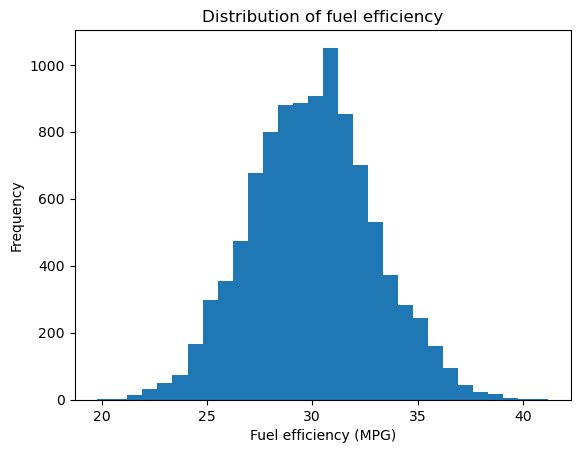

In [7]:
plt.hist(df["fuel_efficiency_mpg"], bins=30)
plt.xlabel("Fuel efficiency (MPG)")
plt.ylabel("Frequency")
plt.title("Distribution of fuel efficiency")
plt.show()

In [8]:
df.columns[df.isna().any()]

Index(['horsepower'], dtype='object')

In [9]:
df["horsepower"].median()

254.0

In [10]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [11]:
# Split the data
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

# Features and target
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]
target = "fuel_efficiency_mpg"

X_train = df_train[features].copy()
y_train = df_train[target]

X_val = df_val[features].copy()
y_val = df_val[target]

# -------------------------
# Option 1: Fill with 0
# -------------------------
X_train_0 = X_train.fillna(0)
X_val_0 = X_val.fillna(0)

model_0 = LinearRegression()
model_0.fit(X_train_0, y_train)

pred_0 = model_0.predict(X_val_0)
rmse_0 = root_mean_squared_error(y_val, pred_0)

print("RMSE with 0:", round(rmse_0, 3))


# -------------------------
# Option 2: Fill with mean
# -------------------------
horsepower_mean = X_train["horsepower"].mean()

X_train_mean = X_train.fillna(horsepower_mean)
X_val_mean = X_val.fillna(horsepower_mean)

model_mean = LinearRegression()
model_mean.fit(X_train_mean, y_train)

pred_mean = model_mean.predict(X_val_mean)
rmse_mean = root_mean_squared_error(y_val, pred_mean)

print("RMSE with mean:", round(rmse_mean, 3))

RMSE with 0: 2.218
RMSE with mean: 2.217


In [12]:
# Fill missing values with 0
X_train = df_train[features].fillna(0)
X_val = df_val[features].fillna(0)

y_train = df_train[target]
y_val = df_val[target]

# Regularization values
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    model = Ridge(alpha=r)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)

    print(r, round(rmse, 5))

0 2.21766
0.01 2.21766
0.1 2.21766
1 2.21766
5 2.21766
10 2.21766
100 2.21767


In [13]:
scores = []

for seed in range(10):

    # 60% train, 40% temporary
    df_train, df_temp = train_test_split(
        df,
        test_size=0.4,
        random_state=seed
    )

    # Split remaining 40% into 20% validation and 20% test
    df_val, df_test = train_test_split(
        df_temp,
        test_size=0.5,
        random_state=seed
    )

    # Features and target
    X_train = df_train[features].fillna(0)
    y_train = df_train[target]

    X_val = df_val[features].fillna(0)
    y_val = df_val[target]

    # Train model without regularization
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict and calculate RMSE
    y_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)

    scores.append(rmse)

# Standard deviation of RMSE scores
std = np.std(scores)

print("RMSE scores:", scores)
print("Standard deviation:", round(std, 4))

RMSE scores: [2.1867094007207117, 2.2210704394042122, 2.2925196288410894, 2.21662699198522, 2.2306275130221236, 2.224374232352427, 2.196125808957578, 2.2256302668957852, 2.1841929964685876, 2.195271309614538]
Standard deviation: 0.0299


In [14]:
# Split the dataset: 60% train, 20% validation, 20% test
df_train, df_temp = train_test_split(
    df,
    test_size=0.4,
    random_state=9
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=9
)

# Combine train and validation
df_train_full = np.concatenate([df_train, df_val])

# Convert back to DataFrame
df_train_full = pd.DataFrame(
    df_train_full,
    columns=df.columns
)

# Features and target
X_train = df_train_full[features].fillna(0)
y_train = df_train_full[target]

X_test = df_test[features].fillna(0)
y_test = df_test[target]

# Train regularized model with r = 0.001
model = Ridge(alpha=0.001)
model.fit(X_train, y_train)

# Predict on test dataset
y_pred = model.predict(X_test)

# RMSE
rmse = root_mean_squared_error(y_test, y_pred)

print(round(rmse, 4))

2.1996
